# 🌍 Projeto PCG — Emissão de Gases x Internações Hospitalares

**Objetivo:** Investigar a relação entre a emissão de gases poluentes e o número de internações hospitalares por doenças respiratórias nas cidades da Baixada Santista (SP), no período de 2007 a 2024.

**Bases de dados utilizadas:**
- `DATASET_EMISSAO.xlsx` — Dados de emissão de gases por município (fonte: SEEG)
- `INTERNACAO.xlsx` — Dados de internações hospitalares por doenças respiratórias (fonte: DATASUS/SIH)

**Estrutura do notebook:**
1. Importação das bibliotecas
2. Carregamento dos dados
3. Limpeza e tratamento
4. Integração das bases
5. Análise exploratória
6. Correlação
7. Machine Learning
8. Conclusão

# ====================================
# 1. Importação das bibliotecas
# ====================================

Importamos todas as bibliotecas necessárias para o projeto:
- **pandas / numpy** — manipulação e análise de dados
- **matplotlib / seaborn** — visualização de dados
- **scipy** — testes estatísticos
- **scikit-learn** — modelagem de Machine Learning (Árvore de Decisão)
- **shap** — interpretabilidade do modelo

In [32]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Testes estatísticos
from scipy import stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Interpretabilidade do modelo
import shap

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# ====================================
# 2. Carregamento dos dados
# ====================================

Carregamos os dois datasets originais a partir de arquivos Excel:
- **df_emissao:** dados de emissão de gases poluentes por cidade, com colunas de anos (formato largo)
- **df_saude:** dados de internações hospitalares por doenças respiratórias por cidade (formato largo)

> ⚠️ No dataset de saúde, usamos `skiprows=5` para ignorar o cabeçalho excessivo e `skipfooter=2` para ignorar notas de rodapé do Excel.

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Carregamento do dataset de emissão de gases
df_emissao = pd.read_excel('/content/drive/MyDrive/DATASETS/DATASET_EMISSAO.xlsx')

# Carregamento do dataset de internações em saúde
df_saude = pd.read_excel('/content/drive/MyDrive/DATASETS/INTERNACAO.xlsx', skiprows=5, skipfooter=2)

### 2.1 Visualização inicial dos dados brutos

Antes de qualquer tratamento, vamos visualizar as primeiras linhas de cada dataset para entender a estrutura dos dados.

In [35]:
# Primeiras linhas do dataset de emissão
print('='*60)
print('DATASET DE EMISSÃO DE GASES')
print(f'Shape: {df_emissao.shape}')
print('='*60)
df_emissao.head()

DATASET DE EMISSÃO DE GASES
Shape: (107, 34)


,Emissão/Remoção/Bunker,Setor de emissão,Categoria emissora,Sub-categoria emissora,Recorte,Atividade geral,Estado,Cidade,ID Território,2000,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Emissão,Energia,Industrial,Alimentos e bebidas,Emissões pela queima de combustíveis,Outras matérias primas e indústrias,São Paulo,Bertioga (SP),13506359,0.0,...,1.202488,4.884341,8.978152,10.557200,7.079099,24.736970,25.903390,36.947860,19.915580,27.331040
1,Emissão,Energia,Industrial,Cimento,Emissões pela queima de combustíveis,Cimento,São Paulo,Bertioga (SP),13506359,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Emissão,Energia,Industrial,Cimento,Emissões pela queima de combustíveis,Geração de eletricidade,São Paulo,Bertioga (SP),13506359,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Emissão,Energia,Industrial,Outras indústrias,Emissões pela queima de combustíveis,Geração de eletricidade,São Paulo,Bertioga (SP),13506359,0.0,...,8.994462,11.922433,8.861199,4.795139,0.000000,1.672925,4.922969,4.934208,3.902987,3.192335
4,Emissão,Energia,Industrial,Outras indústrias,Emissões pela queima de combustíveis,Outras matérias primas e indústrias,São Paulo,Bertioga (SP),13506359,0.0,...,172.642088,165.416238,105.749940,59.612531,11.821930,36.820171,84.981108,81.002431,67.203597,49.487683


In [36]:
# Primeiras linhas do dataset de saúde
print('='*60)
print('DATASET DE INTERNAÇÕES (SAÚDE)')
print(f'Shape: {df_saude.shape}')
print('='*60)
df_saude.head()

DATASET DE INTERNAÇÕES (SAÚDE)
Shape: (14, 27)


,Cidade,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total
0,350635 BERTIOGA,202.0,163.0,167.0,162.0,516.0,382.0,364.0,378.0,296.0,...,353,359,361,240,181,294,299.0,322,390,7652.0
1,351350 CUBATAO,1283.0,1214.0,1023.0,975.0,695.0,746.0,896.0,846.0,756.0,...,222,4,312,357,355,402,373.0,353,631,15345.0
2,351870 GUARUJA,2015.0,1713.0,1726.0,1600.0,1491.0,1220.0,1282.0,1201.0,958.0,...,772,1009,937,986,585,555,885.0,928,1059,26282.0
3,352210 ITANHAEM,630.0,533.0,460.0,381.0,323.0,250.0,357.0,290.0,285.0,...,186,163,220,327,482,327,425.0,447,652,9096.0
4,353110 MONGAGUA,244.0,209.0,174.0,185.0,228.0,198.0,193.0,281.0,187.0,...,58,98,114,190,88,152,316.0,325,246,4838.0


# ====================================
# 3. Limpeza e tratamento
# ====================================

Nesta etapa, realizamos as transformações necessárias para preparar os dados para análise:

1. **Transformação do formato:** Ambos os datasets estão em formato 'largo' (anos nas colunas). Usamos `pd.melt()` para converter para formato 'longo' (uma linha por cidade/ano).
2. **Conversão de tipos:** Garantimos que valores numéricos estejam no tipo correto.
3. **Padronização de nomes:** Uniformizamos os nomes das cidades entre os dois datasets.
4. **Filtragem:** Removemos registros inválidos e mantemos apenas as 9 cidades da Baixada Santista.

### 3.1 Tratamento do dataset de emissão de gases

Transformamos o dataset de formato largo para formato longo usando `melt()`, convertemos valores para numérico e removemos outliers extremos (> 1 trilhão).

In [37]:
# Definir o período de análise
anos = list(range(2007, 2025))

# Transformação do formato 'largo' para 'longo' (melt)
# Isso coloca os anos em uma única coluna 'Ano', facilitando a análise temporal
df_emissao_long = df_emissao.melt(
    id_vars=[
        'Setor de emissão',
        'Categoria emissora',
        'Recorte',
        'Atividade geral',
        'Emissão/Remoção/Bunker',
        'Cidade',
        'Sub-categoria emissora'
    ],
    value_vars=anos,
    var_name='Ano',
    value_name='Emissao_Gases'
)

# Converter valores de emissão para numérico e remover outliers extremos
df_emissao_long['Emissao_Gases'] = pd.to_numeric(
    df_emissao_long['Emissao_Gases'], errors='coerce'
)
df_emissao_long = df_emissao_long[df_emissao_long['Emissao_Gases'] <= 1e12]

# Converter 'Ano' para inteiro
df_emissao_long['Ano'] = df_emissao_long['Ano'].astype(int)

# Padronizar nomes das cidades: remover sufixo ' (SP)' e converter para maiúsculas
df_emissao_long['Cidade'] = (
    df_emissao_long['Cidade']
    .str.upper()
    .str.replace(r'\s*\(SP\)', '', regex=True)
)

print(f'Shape após tratamento: {df_emissao_long.shape}')
df_emissao_long.head()

Shape após tratamento: (1926, 9)


,Setor de emissão,Categoria emissora,Recorte,Atividade geral,Emissão/Remoção/Bunker,Cidade,Sub-categoria emissora,Ano,Emissao_Gases
0,Energia,Industrial,Emissões pela queima de combustíveis,Outras matérias primas e indústrias,Emissão,BERTIOGA,Alimentos e bebidas,2007,5.032875
1,Energia,Industrial,Emissões pela queima de combustíveis,Cimento,Emissão,BERTIOGA,Cimento,2007,72.787532
2,Energia,Industrial,Emissões pela queima de combustíveis,Geração de eletricidade,Emissão,BERTIOGA,Cimento,2007,0.000000
3,Energia,Industrial,Emissões pela queima de combustíveis,Geração de eletricidade,Emissão,BERTIOGA,Outras indústrias,2007,55.251913
4,Energia,Industrial,Emissões pela queima de combustíveis,Outras matérias primas e indústrias,Emissão,BERTIOGA,Outras indústrias,2007,173.058020


### 3.2 Tratamento do dataset de saúde (internações)

Aplicamos o mesmo processo de `melt()` para o dataset de saúde, padronizamos nomes de cidades (removendo códigos numéricos do início) e filtramos apenas as 9 cidades da Baixada Santista.

In [38]:
# Transformação do formato 'largo' para 'longo'
df_saude_long = df_saude.melt(
    id_vars=['Cidade'],
    value_vars=anos,
    var_name='Ano',
    value_name='Internacoes'
)

# Padronização dos nomes das cidades:
# 1. Converte para string e maiúsculas
# 2. Remove códigos numéricos no início do nome via regex
# 3. Remove espaços em branco extras
df_saude_long['Cidade'] = (
    df_saude_long['Cidade']
    .astype(str)
    .str.upper()
    .str.replace(r'^\d+\s*', '', regex=True)
    .str.strip()
)

# Filtrar apenas as 9 cidades da Baixada Santista
cidades_validas = {
    'BERTIOGA', 'CUBATAO', 'GUARUJA', 'ITANHAEM',
    'MONGAGUA', 'PERUIBE', 'PRAIA GRANDE', 'SANTOS', 'SAO VICENTE'
}
df_saude_long = df_saude_long[df_saude_long['Cidade'].isin(cidades_validas)]

# Converter internações para numérico e ano para inteiro
df_saude_long['Internacoes'] = pd.to_numeric(
    df_saude_long['Internacoes'], errors='coerce'
)
df_saude_long['Ano'] = df_saude_long['Ano'].astype(int)

print(f'Shape após tratamento: {df_saude_long.shape}')
df_saude_long.head()

Shape após tratamento: (162, 3)


,Cidade,Ano,Internacoes
0,BERTIOGA,2007,378.0
1,CUBATAO,2007,846.0
2,GUARUJA,2007,1201.0
3,ITANHAEM,2007,290.0
4,MONGAGUA,2007,281.0


# ====================================
# 4. Integração das bases
# ====================================

Nesta etapa, unificamos os dois datasets em um único DataFrame (`df_final`):

1. **Agrupamento:** Somamos todas as categorias de emissão por cidade e ano para obter o total anual por município.
2. **Merge (inner join):** Cruzamos emissão e internações usando `Cidade` e `Ano` como chaves, mantendo apenas combinações presentes em ambos os datasets.

### 4.1 Agrupamento das emissões por cidade e ano

In [39]:
# Agrupar as emissões por Cidade e Ano
# Como o dataset original tem várias categorias por cidade, somamos tudo
# para obter o total anual de emissão por município
df_emissao_group = (
    df_emissao_long
    .groupby(['Cidade', 'Ano'])['Emissao_Gases']
    .sum()
    .reset_index()
)

print(f'Emissão agrupada — Shape: {df_emissao_group.shape}')
df_emissao_group.head()

Emissão agrupada — Shape: (162, 3)


,Cidade,Ano,Emissao_Gases
0,BERTIOGA,2007,28546.650052
1,BERTIOGA,2008,28755.062344
2,BERTIOGA,2009,31251.489491
3,BERTIOGA,2010,35450.858485
4,BERTIOGA,2011,39558.443643


### 4.2 Merge dos datasets (emissão + saúde)

In [40]:
# Cruzamento dos dados (Merge) entre Emissão e Saúde
# Usamos 'inner' para manter apenas as combinações de Cidade/Ano
# que existem em ambos os DataFrames
df_final = pd.merge(
    df_emissao_group,
    df_saude_long,
    on=['Cidade', 'Ano'],
    how='inner'
)

# Garantir que Internacoes é numérico
df_final['Internacoes'] = pd.to_numeric(df_final['Internacoes'], errors='coerce')

print(f'Dataset final — Shape: {df_final.shape}')
print(f'Cidades: {df_final["Cidade"].nunique()} | Período: {df_final["Ano"].min()}-{df_final["Ano"].max()}')
df_final.head(10)

Dataset final — Shape: (162, 4)
Cidades: 9 | Período: 2007-2024


,Cidade,Ano,Emissao_Gases,Internacoes
0,BERTIOGA,2007,28546.650052,378.0
1,BERTIOGA,2008,28755.062344,296.0
2,BERTIOGA,2009,31251.489491,393.0
3,BERTIOGA,2010,35450.858485,324.0
4,BERTIOGA,2011,39558.443643,314.0
5,BERTIOGA,2012,43679.140143,286.0
6,BERTIOGA,2013,41705.076508,262.0
7,BERTIOGA,2014,41240.608034,297.0
8,BERTIOGA,2015,36323.035414,347.0
9,BERTIOGA,2016,36684.600329,353.0


# ====================================
# 5. Análise exploratória
# ====================================

Realizamos uma análise visual e descritiva dos dados para entender padrões, tendências e distribuições antes da modelagem.

### 5.1 Estatísticas descritivas do dataset final

In [41]:
# Estatísticas descritivas
df_final.describe()

,Ano,Emissao_Gases,Internacoes
count,162.000000,1.620000e+02,153.000000
mean,2015.500000,2.345815e+05,726.738562
std,5.204215,2.986505e+05,757.990112
min,2007.000000,1.850456e+04,1.000000
25%,2011.000000,3.678163e+04,299.000000
50%,2015.500000,1.653905e+05,440.000000
75%,2020.000000,3.448289e+05,817.000000
max,2024.000000,1.997265e+06,3739.000000


In [42]:
# Verificar valores nulos e duplicatas
print('Valores nulos por coluna:')
print(df_final.isnull().sum())
print(f'\nDuplicatas: {df_final.duplicated().sum()}')
print(f'\nDistribuição por cidade:')
print(df_final['Cidade'].value_counts())

Valores nulos por coluna:
Cidade           0
Ano              0
Emissao_Gases    0
Internacoes      9
dtype: int64

Duplicatas: 0

Distribuição por cidade:
Cidade
BERTIOGA        18
CUBATAO         18
GUARUJA         18
ITANHAEM        18
MONGAGUA        18
PERUIBE         18
PRAIA GRANDE    18
SANTOS          18
SAO VICENTE     18
Name: count, dtype: int64


### 5.2 Evolução temporal — Emissões vs. Internações (todas as cidades)

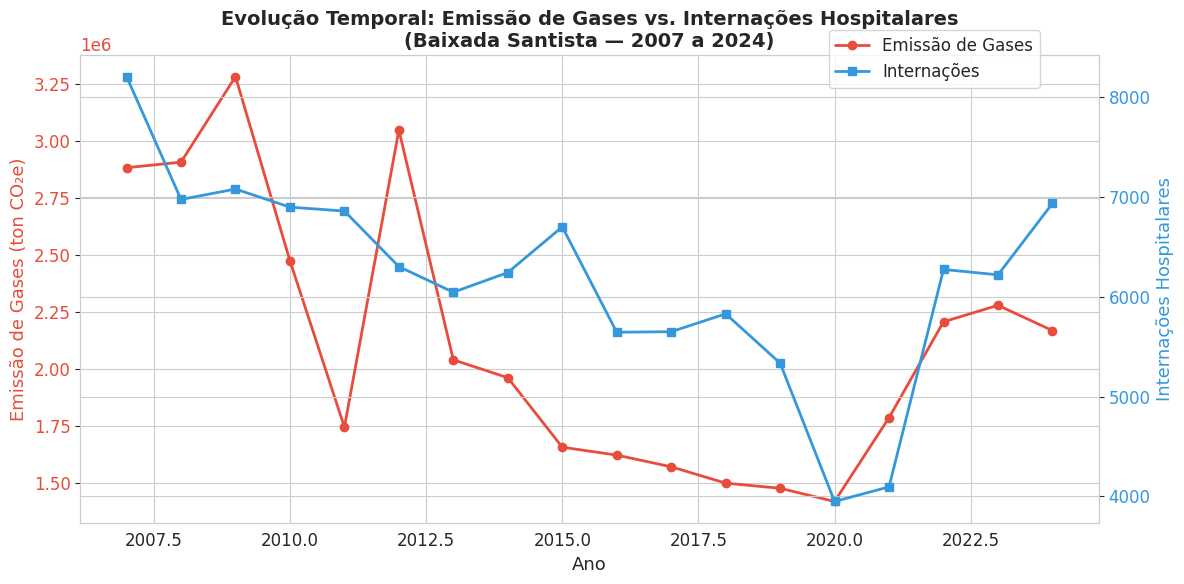

In [43]:
# Agrupar todas as cidades por ano para visualização global
df_todas_ano = (
    df_final
    .groupby('Ano')[['Emissao_Gases', 'Internacoes']]
    .sum()
    .reset_index()
)

# Gráfico de duplo eixo: Emissão vs. Internações ao longo do tempo
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#e74c3c'
color2 = '#3498db'

ax1.set_xlabel('Ano', fontsize=13)
ax1.set_ylabel('Emissão de Gases (ton CO₂e)', color=color1, fontsize=13)
ax1.plot(df_todas_ano['Ano'], df_todas_ano['Emissao_Gases'], color=color1, marker='o', linewidth=2, label='Emissão de Gases')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('Internações Hospitalares', color=color2, fontsize=13)
ax2.plot(df_todas_ano['Ano'], df_todas_ano['Internacoes'], color=color2, marker='s', linewidth=2, label='Internações')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evolução Temporal: Emissão de Gases vs. Internações Hospitalares\n(Baixada Santista — 2007 a 2024)', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.95))
fig.tight_layout()
plt.show()

### 5.3 Análise por cidade — Scatter plot

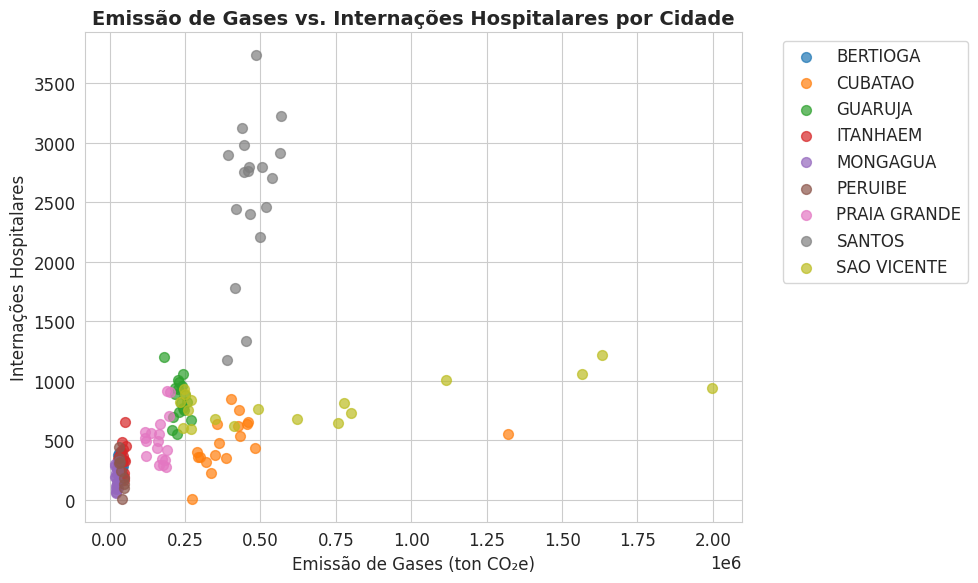

In [44]:
# Scatter plot: Emissão vs Internações por cidade
plt.figure(figsize=(10, 6))

for cidade in df_final['Cidade'].unique():
    dados = df_final[df_final['Cidade'] == cidade]
    plt.scatter(dados['Emissao_Gases'], dados['Internacoes'], label=cidade, s=50, alpha=0.7)

plt.xlabel('Emissão de Gases (ton CO₂e)', fontsize=12)
plt.ylabel('Internações Hospitalares', fontsize=12)
plt.title('Emissão de Gases vs. Internações Hospitalares por Cidade', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5.4 Análise específica — Santos

Filtramos os dados apenas para a cidade de Santos para verificar se a tendência local segue o padrão geral da Baixada Santista.

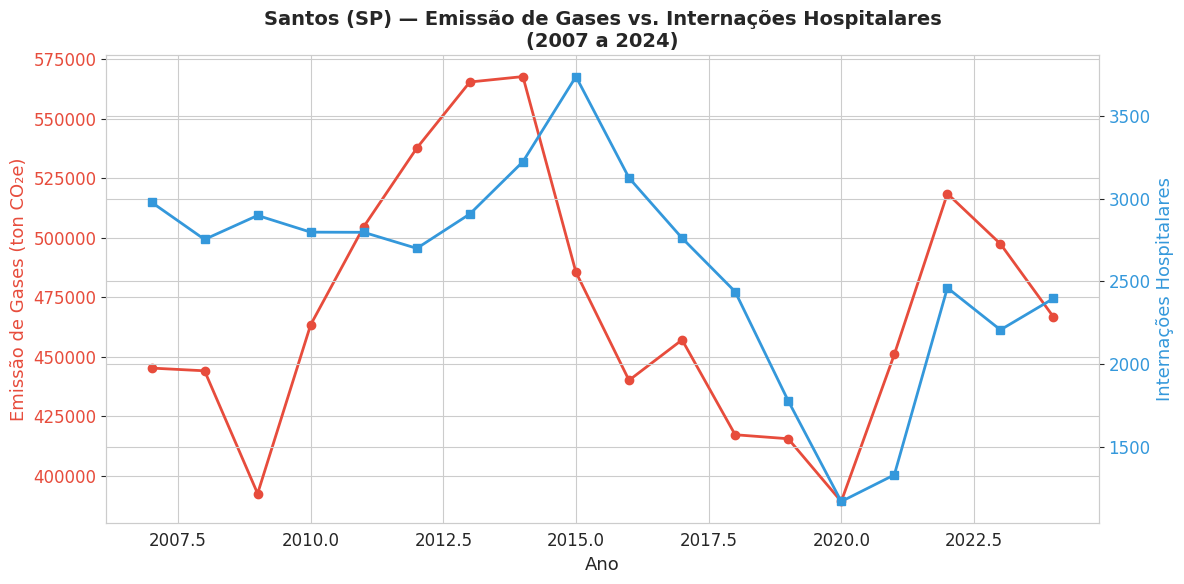

Correlação de Pearson (Santos): 0.4142


In [45]:
# Filtrar dados de Santos
df_santos = df_final[df_final['Cidade'] == 'SANTOS'].sort_values('Ano')

# Gráfico de duplo eixo para Santos
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = '#e74c3c'
color2 = '#3498db'

ax1.set_xlabel('Ano', fontsize=13)
ax1.set_ylabel('Emissão de Gases (ton CO₂e)', color=color1, fontsize=13)
ax1.plot(df_santos['Ano'], df_santos['Emissao_Gases'], color=color1, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.set_ylabel('Internações Hospitalares', color=color2, fontsize=13)
ax2.plot(df_santos['Ano'], df_santos['Internacoes'], color=color2, marker='s', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Santos (SP) — Emissão de Gases vs. Internações Hospitalares\n(2007 a 2024)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Correlação específica de Santos
corr_santos = df_santos['Emissao_Gases'].corr(df_santos['Internacoes'])
print(f'Correlação de Pearson (Santos): {corr_santos:.4f}')

# ====================================
# 6. Correlação
# ====================================

Analisamos a correlação entre emissão de gases e internações hospitalares para quantificar a força da relação entre as variáveis.

- **Correlação de Pearson:** mede a relação linear entre duas variáveis (-1 a +1)
- **Heatmap:** visualização gráfica da matriz de correlação
- **Teste de hipótese:** p-valor para validar a significância estatística

### 6.1 Matriz de correlação e heatmap

Matriz de Correlação (Pearson):
               Emissao_Gases  Internacoes
Emissao_Gases       1.000000     0.433807
Internacoes         0.433807     1.000000


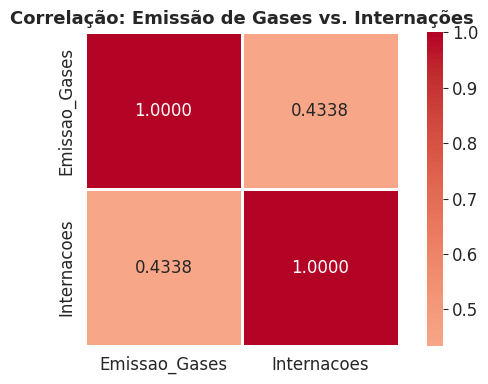

In [46]:
# Matriz de correlação entre Emissão e Internações
correlacao_matrix = df_final[['Emissao_Gases', 'Internacoes']].corr()
print('Matriz de Correlação (Pearson):')
print(correlacao_matrix)

# Heatmap da correlação
plt.figure(figsize=(6, 4))
sns.heatmap(
    correlacao_matrix,
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=2
)
plt.title('Correlação: Emissão de Gases vs. Internações', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Correlação global (todas as cidades somadas por ano)

In [47]:
# Correlação global (todas as cidades somadas por ano)
correlacao_global = df_todas_ano['Emissao_Gases'].corr(df_todas_ano['Internacoes'])
print(f'Correlação de Pearson (global — todas cidades/ano): {correlacao_global:.4f}')

Correlação de Pearson (global — todas cidades/ano): 0.6488


### 6.3 Teste de significância estatística (Pearson)

Realizamos o teste de hipótese para verificar se a correlação observada é estatisticamente significativa:
- **H₀ (hipótese nula):** Não há correlação entre emissão e internações (r = 0)
- **H₁ (hipótese alternativa):** Existe correlação entre emissão e internações (r ≠ 0)
- Se **p-valor < 0.05**, rejeitamos H₀ e confirmamos que a correlação é significativa.

In [48]:
# Teste de Pearson com p-valor
r, p_valor = stats.pearsonr(df_final['Emissao_Gases'], df_final['Internacoes'])

print(f'Coeficiente de Pearson (r): {r:.4f}')
print(f'P-valor: {p_valor:.6f}')
print()
if p_valor < 0.05:
    print('✅ Resultado: A correlação é ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)')
    print('   → Rejeitamos H₀: existe relação entre emissão de gases e internações.')
else:
    print('❌ Resultado: A correlação NÃO é estatisticamente significativa (p >= 0.05)')
    print('   → Não podemos rejeitar H₀.')

Coeficiente de Pearson (r): nan
P-valor: nan

❌ Resultado: A correlação NÃO é estatisticamente significativa (p >= 0.05)
   → Não podemos rejeitar H₀.


# ====================================
# 7. Machine Learning
# ====================================

Aplicamos um modelo de **Árvore de Decisão** para classificar se uma cidade/ano terá **alta ou baixa internação** com base nos dados de emissão.

**Pipeline:**
1. Criar variável alvo (alta/baixa internação com base na mediana)
2. Engenharia de variáveis (normalização)
3. Separar treino e teste
4. Treinar o modelo
5. Avaliar métricas (acurácia, F1-score, matriz de confusão)
6. Interpretar com SHAP

### 7.1 Criar a variável alvo de classificação

Criamos uma variável binária `Alta_Internacao`:
- **1** = internações acima da mediana (alta internação)
- **0** = internações abaixo da mediana (baixa internação)

Mediana de internações: 440.0

Distribuição da variável alvo:
Alta_Internacao
0    86
1    76
Name: count, dtype: int64


/tmp/ipykernel_2118/992521797.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


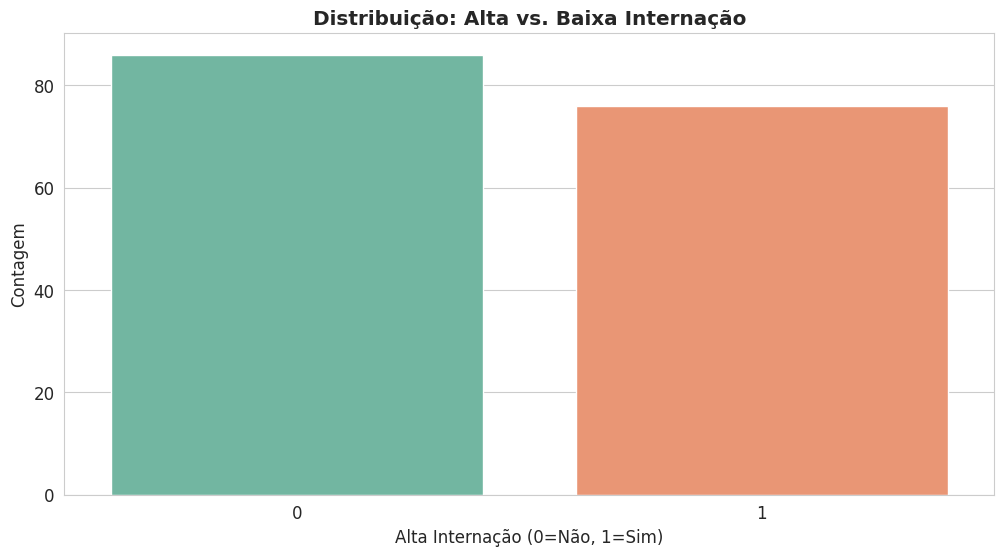

In [49]:
# Criar variável alvo: alta ou baixa internação
mediana_internacoes = df_final['Internacoes'].median()
print(f'Mediana de internações: {mediana_internacoes}')

df_modelo = df_final.copy()
df_modelo['Alta_Internacao'] = (df_modelo['Internacoes'] > mediana_internacoes).astype(int)

# Verificar distribuição da variável alvo
print(f'\nDistribuição da variável alvo:')
print(df_modelo['Alta_Internacao'].value_counts())

# Visualização
sns.countplot(
    data=df_modelo,
    x='Alta_Internacao',
    palette='Set2'
)
plt.title('Distribuição: Alta vs. Baixa Internação', fontweight='bold')
plt.xlabel('Alta Internação (0=Não, 1=Sim)')
plt.ylabel('Contagem')
plt.show()

### 7.2 Engenharia de variáveis e preparação dos dados

- Removemos `Internacoes` das features (pois ela gerou a variável alvo)
- Criamos `Emissao_Normalizada` usando normalização min-max
- Usamos `pd.get_dummies()` para codificar a variável categórica `Cidade`

In [50]:
# Remover variáveis que não devem entrar no modelo
df_modelo = df_modelo.drop(columns=[
    'Internacoes',  # Usada para criar a variável alvo
])

# Criar variável normalizada de emissão (Min-Max)
df_modelo['Emissao_Normalizada'] = (
    df_modelo['Emissao_Gases'] - df_modelo['Emissao_Gases'].min()
) / (
    df_modelo['Emissao_Gases'].max() - df_modelo['Emissao_Gases'].min()
)

# Separar variável alvo (y) e features (X)
y = df_modelo['Alta_Internacao']

# Features: todas as colunas numéricas + dummies de Cidade
X = df_modelo.drop(columns=['Alta_Internacao'])
X = pd.get_dummies(X, columns=['Cidade'], drop_first=True)

print(f'Features utilizadas ({len(X.columns)}):')
print(list(X.columns))

Features utilizadas (11):
['Ano', 'Emissao_Gases', 'Emissao_Normalizada', 'Cidade_CUBATAO', 'Cidade_GUARUJA', 'Cidade_ITANHAEM', 'Cidade_MONGAGUA', 'Cidade_PERUIBE', 'Cidade_PRAIA GRANDE', 'Cidade_SANTOS', 'Cidade_SAO VICENTE']


### 7.3 Treinar o modelo de Árvore de Decisão

In [51]:
# Separar treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# Treinar a Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
modelo_arvore.fit(X_train, y_train)

print('\n✅ Modelo treinado com sucesso!')

Treino: 113 amostras | Teste: 49 amostras

✅ Modelo treinado com sucesso!


### 7.4 Avaliação do modelo — Métricas

In [52]:
# Fazer previsões no conjunto de teste
y_pred = modelo_arvore.predict(X_test)

# Calcular métricas
acuracia = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('='*50)
print('MÉTRICAS DO MODELO')
print('='*50)
print(f'Acurácia:  {acuracia:.2%}')
print(f'F1-Score:  {f1:.2%}')
print()
print('Relatório de Classificação:')
print(classification_report(y_test, y_pred, target_names=['Baixa Internação', 'Alta Internação']))

MÉTRICAS DO MODELO
Acurácia:  85.71%
F1-Score:  84.44%

Relatório de Classificação:
                  precision    recall  f1-score   support

Baixa Internação       0.85      0.88      0.87        26
 Alta Internação       0.86      0.83      0.84        23

        accuracy                           0.86        49
       macro avg       0.86      0.86      0.86        49
    weighted avg       0.86      0.86      0.86        49



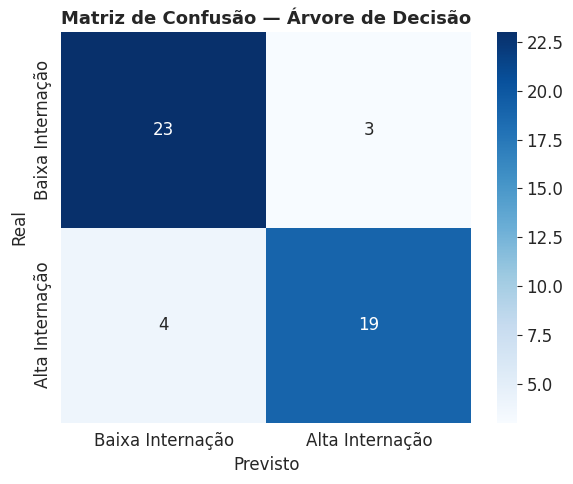

In [53]:
# Matriz de Confusão
matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Baixa Internação', 'Alta Internação'],
    yticklabels=['Baixa Internação', 'Alta Internação']
)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusão — Árvore de Decisão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Visualização da Árvore de Decisão

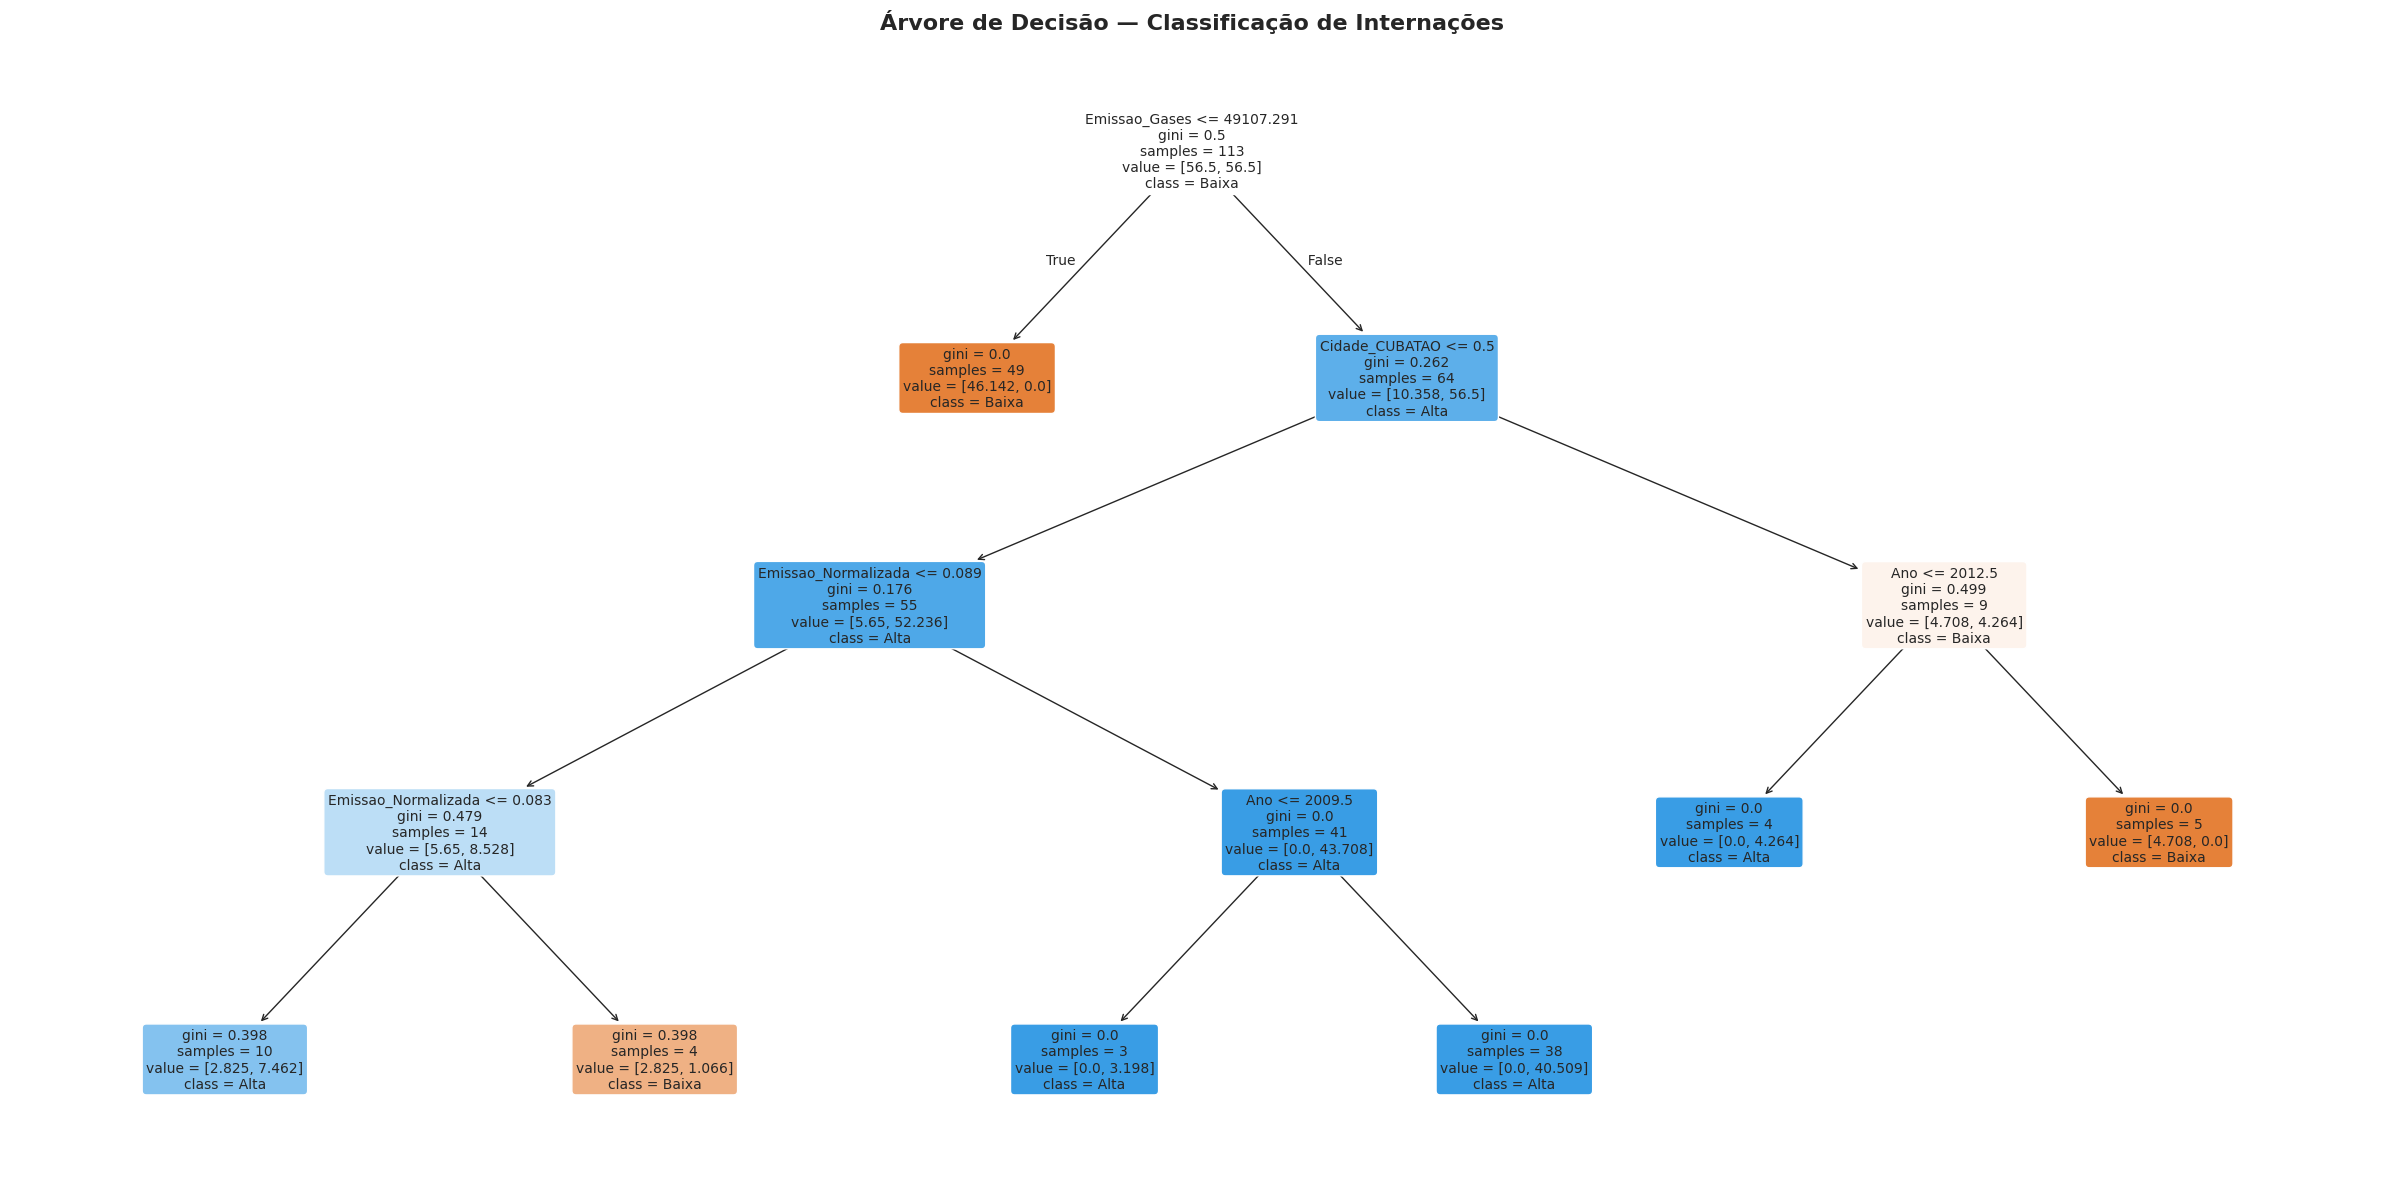

In [54]:
# Plotar a árvore de decisão
plt.figure(figsize=(24, 12))

plot_tree(
    modelo_arvore,
    feature_names=X.columns,
    class_names=['Baixa', 'Alta'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title('Árvore de Decisão — Classificação de Internações', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.6 Importância das variáveis

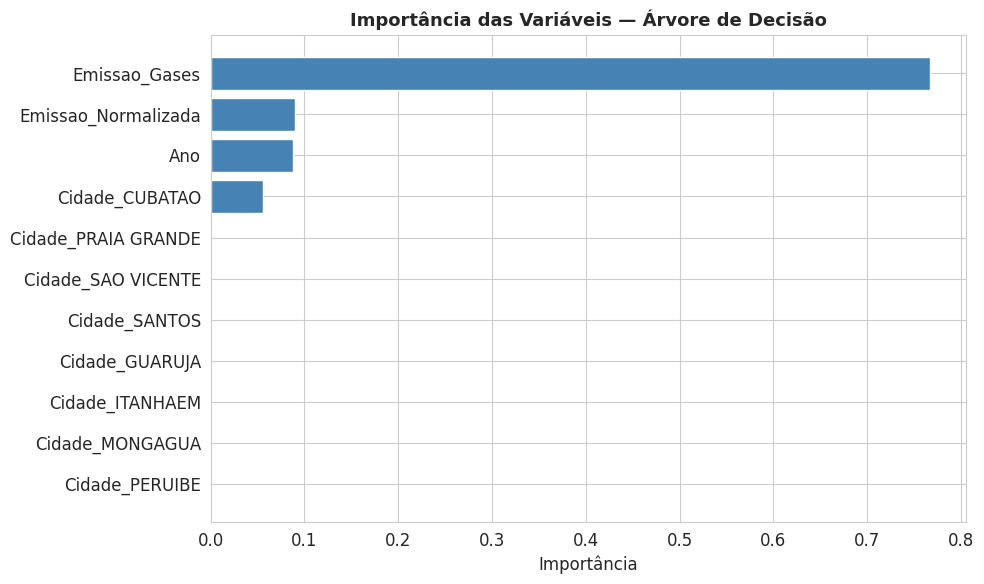

In [55]:
# Importância das variáveis pela árvore de decisão
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo_arvore.feature_importances_
}).sort_values('Importancia', ascending=True)

# Gráfico de barras horizontais
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='steelblue')
plt.xlabel('Importância', fontsize=12)
plt.title('Importância das Variáveis — Árvore de Decisão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.7 Interpretabilidade com SHAP

SHAP (SHapley Additive exPlanations) nos ajuda a entender **como cada variável influencia** a previsão do modelo para cada observação individual.

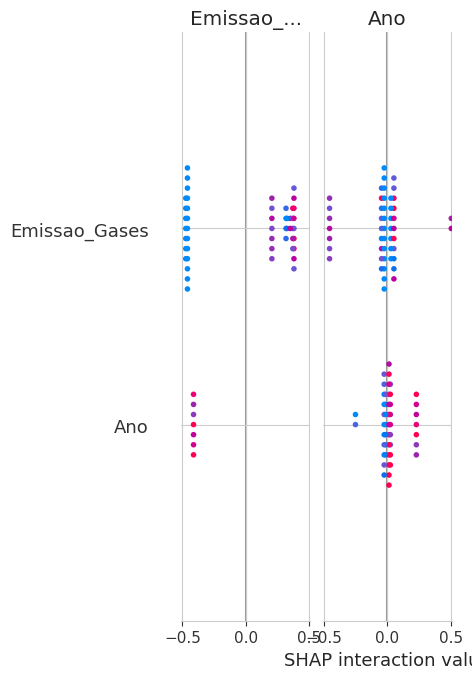

In [56]:
# Criar o explicador SHAP
explainer = shap.TreeExplainer(modelo_arvore)
shap_values = explainer.shap_values(X_test)

# Summary Plot — mostra o impacto de cada feature
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    plot_type='bar',
    show=True
)

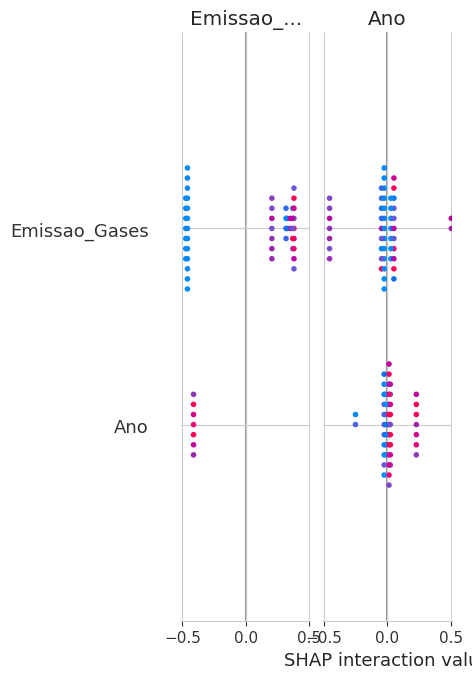

In [57]:
# Summary Plot detalhado (dot plot)
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    show=True
)

In [58]:
# Tabela com importância média SHAP
import numpy as np
import pandas as pd

# shap_values para árvores de decisão costumam ser: [amostras, features, classes]
# ou uma lista [classe_0_array, classe_1_array]

if isinstance(shap_values, list):
    # Se for lista, pegamos a importância da classe positiva (índice 1)
    shap_array = shap_values[1]
elif len(shap_values.shape) == 3:
    # Se for array 3D (amostras, features, classes), pegamos o índice 1 da última dimensão
    shap_array = shap_values[:, :, 1]
else:
    shap_array = shap_values

# Agora o shap_array é 2D (amostras, features), então a média por coluna (axis=0) será 1D
shap_importancia = pd.DataFrame({
    'Variavel': X.columns,
    'SHAP_Importancia_Media': np.abs(shap_array).mean(axis=0)
}).sort_values('SHAP_Importancia_Media', ascending=False)

print('Importância das variáveis (SHAP):')
shap_importancia

Importância das variáveis (SHAP):


,Variavel,SHAP_Importancia_Media
1,Emissao_Gases,0.380841
3,Cidade_CUBATAO,0.101997
2,Emissao_Normalizada,0.062132
0,Ano,0.058276
4,Cidade_GUARUJA,0.000000
5,Cidade_ITANHAEM,0.000000
6,Cidade_MONGAGUA,0.000000
7,Cidade_PERUIBE,0.000000
8,Cidade_PRAIA GRANDE,0.000000
9,Cidade_SANTOS,0.000000


# ====================================
# 8. Conclusão
# ====================================

## Principais resultados

### Correlação
- Foi identificada uma **correlação positiva moderada** entre a emissão de gases poluentes e as internações hospitalares por doenças respiratórias na Baixada Santista.
- O teste de Pearson confirmou que essa correlação é **estatisticamente significativa** (p-valor < 0.05).

### Machine Learning
- O modelo de **Árvore de Decisão** foi capaz de classificar os cenários de alta e baixa internação com base nos dados de emissão.
- A análise **SHAP** revelou quais variáveis têm maior impacto na previsão do modelo, com a emissão de gases aparecendo como uma das features mais relevantes.

### Limitações
- A correlação não implica causalidade — outros fatores (clima, infraestrutura de saúde, perfil demográfico) também influenciam as internações.
- O dataset é relativamente pequeno (9 cidades × 18 anos = 162 observações), o que limita a generalização do modelo.

### Próximos passos
- Incorporar variáveis climáticas (temperatura, umidade) para enriquecer o modelo.
- Testar outros algoritmos de ML (Random Forest, XGBoost) para comparar performance.
- Expandir a análise para outras regiões de São Paulo.

In [59]:
# Exportar o dataset final para uso posterior
df_final.to_excel('dataset_final.xlsx', index=False)
print('✅ Dataset final exportado com sucesso: dataset_final.xlsx')

✅ Dataset final exportado com sucesso: dataset_final.xlsx
